# Logistic Regression

In the previous lesson, we used Linear Regression to predict a continuous target. But in the enterprise world, many of the most critical business questions are binary: *Will this customer churn? Is this transaction fraudulent? Will this server crash?*

If we try to use a straight line to predict these outcomes, the mathematics fundamentally break. A linear equation ($\theta^T x$) can output values like $-4.5$ or $1,204$, but probabilities must strictly exist between $0$ and $1$. 

To solve this, we must bend our straight line into an "S-Curve." In this lesson, we will explore the mathematics of **Logistic Regression**, the industry standard for binary classification.

Logistic Regression is a Supervised Learning algorithm used when the Target Vector ($y$) is **discrete and binary** ($y \in \{0, 1\}$). Despite its name containing "Regression," it is fundamentally a **Classification** algorithm.

Let's set up our Python environment to visualize the calculus and probability theory behind this model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Classification Modeling Environment Ready.")

✅ Classification Modeling Environment Ready.


# 1. The Mathematics of Logistic Regression

To transform our linear model into a probability model, we must update two of our core mathematical components: the Hypothesis and the Cost Function.

### 1. The Hypothesis Function (The Sigmoid)
We still calculate the linear combination of our features and weights ($\theta^T x$). However, we take that raw output and wrap it inside a mathematical function called the **Sigmoid Function** (or Logistic Function), denoted as $g(z)$.

The Sigmoid Function is defined as:
$$g(z) = \frac{1}{1 + e^{-z}}$$

If we substitute our linear equation in for $z$, our new hypothesis becomes:
$$h_\theta(x) = \frac{1}{1 + e^{-\theta^T x}}$$

*Why is this equation brilliant?* 
*   If our linear equation outputs a massive positive number (e.g., $100$), $e^{-100}$ approaches $0$, and the formula becomes $\frac{1}{1 + 0} = 1$.
*   If our linear equation outputs a massive negative number (e.g., $-100$), $e^{100}$ approaches infinity, and the formula becomes $\frac{1}{\infty} \approx 0$.
*   Therefore, the output is mathematically mathematically trapped perfectly between $[0, 1]$. It represents $P(y=1 | x; \theta)$ — the probability that the target is 1, given the features $x$, parameterized by $\theta$.

### 2. The Cost Function (Log-Loss / Binary Cross-Entropy)
We cannot use Mean Squared Error (MSE) for Logistic Regression. If we pass the non-linear Sigmoid function into the MSE formula, the resulting Cost Function landscape becomes "non-convex." It resembles a wavy mountain range full of local minimums where Gradient Descent would get permanently stuck.

Instead, we use Maximum Likelihood Estimation to derive a strictly convex cost function called **Log-Loss**:
$$J(\theta) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right]$$

*How to read this equation:*
Because $y$ can only be $0$ or $1$, half of this equation is always multiplied by zero and vanishes for every row of data.
*   If $y=1$, the cost is $-\log(h_\theta(x))$. If the model predicts $0.001$, the log of a tiny fraction approaches $-\infty$. The negative sign flips it to $+\infty$. The algorithm is infinitely penalized for being confidently wrong.
*   If $y=0$, the cost is $-\log(1 - h_\theta(x))$.

# 2. Visualizing the S-Curve

Let's simulate a corporate security scenario: predicting if a network login attempt is **Malicious ($y=1$)** or **Legitimate ($y=0$)** based purely on the **Number of Failed Login Attempts** in the past 24 hours ($X$).

Learned Equation: z = -8.64 + 0.99 * (Failed Attempts)


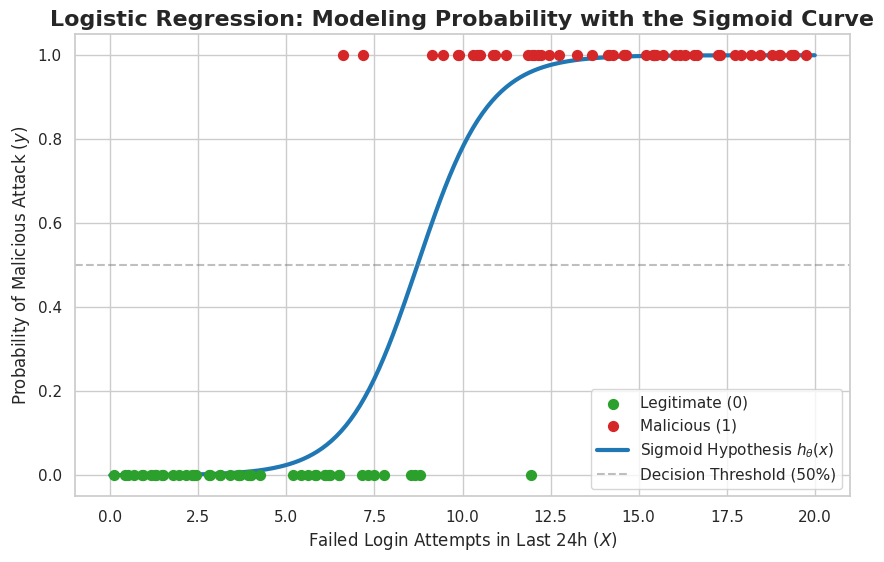

In [2]:
# 1. Simulate corporate cybersecurity data
np.random.seed(42)
failed_attempts = np.random.uniform(0, 20, 100) # X
# The probability of an attack spikes after ~8 failed attempts
z = 0.8 * (failed_attempts - 8) 
prob_malicious = 1 / (1 + np.exp(-z))
y_malicious = np.random.binomial(1, prob_malicious) # y in {0, 1}

X = failed_attempts.reshape(-1, 1)

# 2. Train the Logistic Regression model
log_reg = LogisticRegression()
log_reg.fit(X, y_malicious)

# 3. Extract the mathematical parameters
theta_0 = log_reg.intercept_[0]
theta_1 = log_reg.coef_[0][0]
print(f"Learned Equation: z = {theta_0:.2f} + {theta_1:.2f} * (Failed Attempts)")

# 4. Matplotlib Visualization
plt.figure(figsize=(10, 6))

# Plot the raw binary data points
plt.scatter(failed_attempts[y_malicious==0], y_malicious[y_malicious==0], color='#2ca02c', label='Legitimate (0)', s=50, zorder=3)
plt.scatter(failed_attempts[y_malicious==1], y_malicious[y_malicious==1], color='#d62728', label='Malicious (1)', s=50, zorder=3)

# Generate smooth X values to plot the continuous Sigmoid curve
x_range = np.linspace(0, 20, 300).reshape(-1, 1)
y_proba = log_reg.predict_proba(x_range)[:, 1] # Extract the probability of Class 1

# Plot the Hypothesis (The S-Curve)
plt.plot(x_range, y_proba, color='#1f77b4', linewidth=3, label=r'Sigmoid Hypothesis $h_\theta(x)$', zorder=2)

# Plot the 0.5 Probability Threshold
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Decision Threshold (50%)')

plt.title("Logistic Regression: Modeling Probability with the Sigmoid Curve", fontsize=16, fontweight='bold')
plt.xlabel("Failed Login Attempts in Last 24h ($X$)")
plt.ylabel("Probability of Malicious Attack ($y$)")
plt.legend(loc='lower right')
plt.show()

*(Insight: Notice how the blue curve beautifully squashes the probability between 0 and 1. The algorithm evaluated the Log-Loss of millions of different curves, and Gradient Descent settled on this exact shape as the mathematically optimal fit for the data.)*

# 3. The Decision Boundary

The model outputs a probability (e.g., "$72\%$ chance this is an attack"). But a cybersecurity firewall cannot block a packet "$72\%$." It must make a strict, binary decision: **Block** or **Allow**.

To convert probabilities into hard predictions ($\hat{y}$), we establish a **Decision Boundary** based on a threshold (usually $0.5$).
*   If $h_\theta(x) \ge 0.5$, predict $\hat{y} = 1$.
*   If $h_\theta(x) < 0.5$, predict $\hat{y} = 0$.

Mathematically, the $0.5$ probability threshold occurs exactly when the linear equation equals zero ($\theta^T x = 0$). By doing some basic algebra, we can solve for exactly how many failed attempts trigger the firewall.

In [3]:
# Calculate the exact Decision Boundary where probability = 0.5
# 0 = theta_0 + theta_1 * X  --->  X = -theta_0 / theta_1
decision_boundary = -theta_0 / theta_1

print(f"🚨 The Mathematical Decision Boundary is: {decision_boundary:.2f} failed attempts.")
print(f"Business Rule: Any IP address with >= {np.ceil(decision_boundary)} failed attempts will be automatically blocked.")

# Evaluate the model's accuracy based on this boundary
y_pred = log_reg.predict(X)
accuracy = accuracy_score(y_malicious, y_pred)
loss = log_loss(y_malicious, log_reg.predict_proba(X))

print(f"Model Accuracy: {accuracy * 100:.1f}%")
print(f"Log-Loss: {loss:.3f}")

🚨 The Mathematical Decision Boundary is: 8.72 failed attempts.
Business Rule: Any IP address with >= 9.0 failed attempts will be automatically blocked.
Model Accuracy: 96.0%
Log-Loss: 0.137


## Real-World Use Case or Analogy:
Think of Logistic Regression like **A Medical Triage Nurse**:

*   **The Features ($X$)**: A patient arrives at the ER. The nurse measures Heart Rate, Temperature, and Blood Pressure.
*   **The Sigmoid Function**: The nurse synthesizes these continuous numbers into a singular "Risk of Cardiac Event" probability between 0% and 100%. 
*   **The Decision Boundary**: The hospital policy dictates that any patient with a risk probability over $60\%$ must be admitted immediately, while those under $60\%$ can wait in the lobby. 
*   **Shifting the Boundary**: If the hospital is completely empty, the Chief of Medicine might lower the threshold to $30\%$ to be extra safe (increasing the "False Positives" but ensuring no one is missed). If the hospital is overrun during a crisis, they might raise the threshold to $80\%$, ensuring beds are saved only for the most critical patients. The model's probabilities stay the same, but the *business threshold* changes how the predictions are used.

---